# Load PV data (PV)

In [1]:
import pandas as pd

In [2]:
pv = pd.read_csv('Wülknitz Energy Meter Janitza UMG 104 2025.csv', 
                 sep=';', 
                 decimal='.', 
                 thousands = ',',
                 index_col=0)
pv.index = pd.to_datetime(pv.index, format='%d.%m.%Y %H:%M:%S')

In [3]:
pv.describe()

,Wülknitz Janitza UMG 104 AC Power L1234 [W] [avg],Unnamed: 2
count,3.475400e+04,0.0
mean,-1.448682e+06,NaN
std,2.442719e+06,NaN
min,-9.908187e+06,NaN
25%,-2.004538e+06,NaN
50%,3.614303e+04,NaN
75%,3.842653e+04,NaN
max,6.810601e+04,NaN


In [4]:
pv.rename(columns={'Wülknitz Janitza UMG 104 AC Power L1234 [W] [avg]':'PV'}, inplace=True)
pv.drop(columns=['Unnamed: 2'], inplace=True)

In [5]:
pv.tail()

,PV
Date,
2025-12-31 23:00:00,39308.73333
2025-12-31 23:15:00,40321.44000
2025-12-31 23:30:00,39494.75333
2025-12-31 23:45:00,39553.67333
2026-01-01 00:00:00,39463.30714


In [6]:
pv.fillna(0)

,PV
Date,
2025-01-01 00:15:00,39733.30667
2025-01-01 00:30:00,39263.46667
2025-01-01 00:45:00,38906.78667
2025-01-01 01:00:00,39735.40000
2025-01-01 01:15:00,39270.38667
...,...
2025-12-31 23:00:00,39308.73333
2025-12-31 23:15:00,40321.44000
2025-12-31 23:30:00,39494.75333


In [7]:
pv.PV = pv.PV * -1 / 1000000

<Axes: xlabel='Date'>

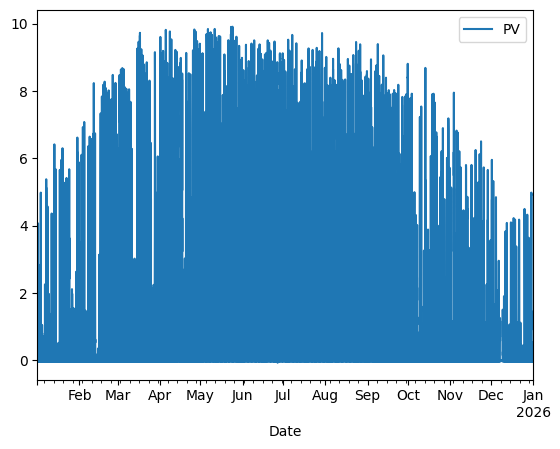

In [8]:
pv.plot()

In [9]:
pv.to_csv('2025_pv.csv')